# 🔗 VeriFact - Fake News Detector
### Integrating 3 Independent Models with Equal Weight

| Branch | Notebook | What it does | Output |
|--------|----------|--------------|--------|
| **Branch 1** | `FineFake_BLIP2_NEW_FINAL` | BLIP-2 image captioning + Sentence-BERT similarity | Probability (0–1) |
| **Branch 2** | `ifndtest` | BiLSTM on IFND text dataset | Probability (0–1) |
| **Branch 3** | `text_ddg` | DuckDuckGo OSINT + Random Forest | Probability (0–1) |

**Final Score** = (Branch1_prob + Branch2_prob + Branch3_prob) / 3  
**Final Label** = FAKE if Final Score ≥ 0.5 else REAL

---
**Requirements before running:**
- All 3 pre-trained models saved to Google Drive (see Section 1)
- GPU runtime recommended (for BLIP-2)

## 1. Install Dependencies

In [1]:
!pip install -q transformers accelerate sentencepiece sentence-transformers \
               Pillow scikit-learn pandas tqdm bitsandbytes ddgs tensorflow openpyxl
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 73.2 MB/s eta 0:00:00
All packages installed.


## 2. Mount Drive & Set Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── MASTER PATHS ────────────────────────────────────────────────────────────
BASE_DIR        = Path('/content/drive/MyDrive/FineFake_branch3')
EXCEL_PATH      = BASE_DIR / 'finefake_perfect.xlsx'
IMG_ROOT        = BASE_DIR / 'Image'

# Branch 1 — BLIP-2 (Image + Text)
B1_MODEL_PATH   = BASE_DIR / 'outputs' / 'best_clf.pkl'
B1_SCALER_PATH  = BASE_DIR / 'outputs' / 'scaler.pkl'

# Branch 2 — BiLSTM (Text)
B2_MODEL_PATH   = BASE_DIR / 'outputs' / 'fake_news_lstm.h5'
B2_TOKENIZER_PATH = BASE_DIR / 'outputs' / 'tokenizertextLSTM.pkl'

# Branch 3 — OSINT (Internet Search)
B3_MODEL_PATH   = BASE_DIR / 'outputs' / 'branch3_v2_model.pkl'
B3_SNIPPET_PATH = BASE_DIR / 'outputs' / 'branch3_v2_snippet_vectorizer.pkl'
B3_DOMAIN_PATH  = BASE_DIR / 'outputs' / 'branch3_v2_domain_vectorizer.pkl'
# ────────────────────────────────────────────────────────────────────────────

print('Paths configured.')
for p in [B1_MODEL_PATH, B2_MODEL_PATH, B3_MODEL_PATH]:
    print(f'  {p.name:45s} exists={p.exists()}')

Mounted at /content/drive
Paths configured.
  best_clf.pkl                                  exists=True
  fake_news_lstm.h5                             exists=True
  branch3_v2_model.pkl                          exists=True


## 3. Global Imports

In [3]:
!pip install -q transformers accelerate sentencepiece sentence-transformers Pillow scikit-learn pandas tqdm duckduckgo-search imagehash
print('✅ Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.9 MB/s eta 0:00:00
✅ Dependencies installed.


In [4]:
import os, re, time, warnings, pickle, requests, imagehash
import numpy as np
import pandas as pd
import joblib
import torch
from PIL import Image
from io import BytesIO
from urllib.parse import urlparse
from ddgs import DDGS
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ PyTorch Device: {DEVICE}')

✅ PyTorch Device: cuda


In [5]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ TensorFlow memory growth enabled.")
  except RuntimeError as e:
    print(e)

✅ TensorFlow memory growth enabled.


# 3. Loading the Models:

In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
B2_MAX_LEN = 100

print('Loading BiLSTM model...')
b2_model = tf.keras.models.load_model(str(B2_MODEL_PATH))
with open(B2_TOKENIZER_PATH, 'rb') as f:
    b2_tokenizer = pickle.load(f)
print('✅ Branch 2 Ready.')

Loading BiLSTM model...


✅ Branch 2 Ready.


## BRANCH 1 — Vision Model (FineFake)

In [7]:
import gc
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from sentence_transformers import SentenceTransformer, util

gc.collect()
torch.cuda.empty_cache()

print('Loading BLIP-2 to GPU...')
BLIP2_MODEL = 'Salesforce/blip2-opt-2.7b'
blip2_processor = Blip2Processor.from_pretrained(BLIP2_MODEL)
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_MODEL, torch_dtype=torch.float16, device_map="auto"
)
blip2_model.eval()

print('Loading Sentence-BERT...')
sim_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=DEVICE)
print('✅ Branch 1 Deep Learning Ready.')

Loading BLIP-2 to GPU...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Branch 1 Deep Learning Ready.


# Branch 1 and Branch 3 Classifiers:

In [8]:
print('Loading Branch 1 Classifiers...')
b1_clf    = joblib.load(B1_MODEL_PATH)
b1_scaler = joblib.load(B1_SCALER_PATH)

print('Loading Branch 3 OSINT Brain...')
b3_model = joblib.load(B3_MODEL_PATH)
b3_snippet_vocab = joblib.load(B3_SNIPPET_PATH)
b3_domain_vocab = joblib.load(B3_DOMAIN_PATH)
ddgs = DDGS()

print('✅ All Machine Learning Brains Loaded.')

Loading Branch 1 Classifiers...
Loading Branch 3 OSINT Brain...
✅ All Machine Learning Brains Loaded.


# 4. The Prediction Engine

In [9]:
# --- BRANCH 1 HELPERS ---
@torch.no_grad()
def b1_generate_caption(image):
    if image is None: return ''
    try:
        inputs = blip2_processor(images=image, return_tensors='pt').to(DEVICE, torch.float16)
        out = blip2_model.generate(**inputs, max_new_tokens=40)
        return blip2_processor.decode(out[0], skip_special_tokens=True).strip()
    except: return ''

def b1_predict_prob(image_path: str, text: str) -> float:
    try:
        img = Image.open(image_path).convert('RGB') if image_path else None
        caption = b1_generate_caption(img)
        emb_c = sim_model.encode(caption, convert_to_tensor=True)
        emb_t = sim_model.encode(str(text), convert_to_tensor=True)
        sim = float(util.cos_sim(emb_c, emb_t).item())
        feats = b1_scaler.transform([[sim, len(caption.split())]])
        return float(b1_clf.predict_proba(feats)[0][1])
    except Exception: return 0.5

# --- BRANCH 2 HELPERS ---
def b2_clean_text(text: str) -> str:
    if pd.isna(text): return ''
    text = str(text).lower()
    for pattern in [r'^fact check[:\-]?\s*', r'^viral[:\-]?\s*', r'^fake[:\-]?\s*']:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    return text.strip()

def b2_predict_prob(text: str) -> float:
    try:
        clean = b2_clean_text(text)
        seq = b2_tokenizer.texts_to_sequences([clean])
        padded = pad_sequences(seq, maxlen=B2_MAX_LEN, padding='post')
        return float(1.0 - b2_model.predict(padded, verbose=0)[0][0])
    except Exception: return 0.5

# --- BRANCH 3 HELPERsS OSINT BRANCH (Smart Search + Hybrid Override) ---
def b3_predict_prob(text: str, image_path: str = None) -> float:
    try:
        # ====================================================
        # 🧠 THE SMART SEARCH ENGINE
        # ====================================================
        # 1. Strip URLs but KEEP numbers and quotes
        clean_text = re.sub(r'http\S+', '', str(text))
        clean_text = re.sub(r'[^a-zA-Z0-9\s"\'\-]', ' ', clean_text)

        # 2. Delete useless fluff words so we reach the core claim faster
        stopwords = {"a", "an", "the", "is", "are", "was", "were", "in", "on", "at", "to", "for", "of", "who", "that", "this", "it", "with", "and", "by", "from", "their", "anyone"}
        words = [w for w in clean_text.split() if w.lower() not in stopwords]

        # 3. Grab the first 12 HIGH-VALUE words
        headline = " ".join(words[:12])

        # Search the live internet
        snippets_combined, domains_combined = "", ""
        results = list(ddgs.text(headline, max_results=5))
        for res in results:
            snippets_combined += str(res.get('body', '')).lower() + " || "
            domains_combined += urlparse(res.get('href', '')).netloc.replace('www.', '').lower() + " "

        # ====================================================
        # 🛡️ THE HYBRID OVERRIDE
        # ====================================================
        fact_checkers = ['snopes', 'politifact', 'factcheck', 'reuters', 'apnews', 'leadstories', 'fullfact', 'afp', 'usatoday']
        debunk_words = ['false', 'fake', 'hoax', 'debunked', 'misleading', 'altered', 'satire', 'scam', 'unsupported', 'unproven']
        true_words = ['true', 'correct', 'accurate', 'authentic', 'verified', 'real']

        has_fc = any(fc in domains_combined for fc in fact_checkers)
        has_debunk = any(dw in snippets_combined for dw in debunk_words)
        has_true = any(tw in snippets_combined for tw in true_words)

        if has_fc and has_debunk: return 0.95  # Explicitly Debunked
        if has_fc and has_true and not has_debunk: return 0.05  # Explicitly Verified

        # ====================================================
        # 🤖 FALLBACK TO RANDOM FOREST
        # ====================================================
        live_snippet_features = b3_snippet_vocab.transform([snippets_combined]).toarray()
        live_domain_features = b3_domain_vocab.transform([domains_combined]).toarray()

        hash_dist, has_exif = -1, 0
        if image_path:
            try:
                local_hash = imagehash.phash(Image.open(image_path))
                ddg_imgs = list(ddgs.images(headline, max_results=1))
                if ddg_imgs:
                    resp = requests.get(ddg_imgs[0]['image'], timeout=3)
                    hash_dist = local_hash - imagehash.phash(Image.open(BytesIO(resp.content)))
            except: pass

        fc_count = sum(1 for d in fact_checkers if d in domains_combined)
        debunk_count = sum(snippets_combined.count(w) for w in debunk_words)
        legit_count = sum(snippets_combined.count(w) for w in true_words)

        X_live = np.hstack((
            live_snippet_features, live_domain_features,
            [[hash_dist]], [[has_exif]],
            [[fc_count]], [[debunk_count]], [[legit_count]]
        ))

        classes = list(b3_model.classes_)
        fake_idx = classes.index(0)
        return float(b3_model.predict_proba(X_live)[0][fake_idx])

    except Exception:
        return 0.5
print("✅ All Helpers defined.")

✅ All Helpers defined.


# 5. Defining Weights

In [10]:
def ensemble_predict(text: str, image_path: str = None, threshold: float = 0.5) -> dict:


    w1, w2, w3 = 0.45, 0.05, 0.5

    p1 = b1_predict_prob(image_path, text)
    p2 = b2_predict_prob(text)
    p3 = b3_predict_prob(text, image_path)

    final_score = (w1 * p1) + (w2 * p2) + (w3 * p3)
    final_label = 'FAKE' if final_score >= threshold else 'REAL'

    return {
        'branch1_prob_fake': round(p1, 4),
        'branch2_prob_fake': round(p2, 4),
        'branch3_prob_fake': round(p3, 4),
        'final_score'      : round(final_score, 4),
        'final_label'      : final_label,
    }
print("✅ Tri-Modal Ensemble Ready.")

✅ Tri-Modal Ensemble Ready.


# 6. Testing

### Weights summary (**1000 Tests**)

| Branch | Weight
| :--- | :---:
| **Branch 1 : Vision Model** | 33% |  
| **Branch 2 : BiLSTM** | 33% |
| **Branch 3 : OSINT** | 34% |

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

TEST_CSV_PATH = '/content/drive/MyDrive/FineFake_branch3/finefake_test_1000.csv'
df_test = pd.read_csv(TEST_CSV_PATH)

print(f"Running Final Tri-Modal Test on {len(df_test)} rows. (This takes ~20 mins due to live OSINT searches)...")

true_labels, b1_preds, b2_preds, b3_preds, final_preds = [], [], [], [], []

for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    text = str(row['text'])
    true_label = int(row['label'])

    img_val = row['image_path'] if 'image_path' in df_test.columns else row['image']
    img_filename = Path(str(img_val)).name
    img_path = None

    if (IMG_ROOT / img_filename).exists():
        img_path = str(IMG_ROOT / img_filename)
    else:
        for subfolder in IMG_ROOT.iterdir():
            if subfolder.is_dir() and (subfolder / img_filename).exists():
                img_path = str(subfolder / img_filename)
                break

    result = ensemble_predict(text, image_path=img_path)

    true_labels.append(true_label)
    b1_preds.append(0 if result['branch1_prob_fake'] >= 0.5 else 1)
    b2_preds.append(0 if result['branch2_prob_fake'] >= 0.5 else 1)
    b3_preds.append(0 if result['branch3_prob_fake'] >= 0.5 else 1)
    final_preds.append(0 if result['final_label'] == 'FAKE' else 1)

print('\n' + '='*50)
print(' 📊 INDIVIDUAL BRANCH REPORT CARDS')
print('='*50)
print(f"🟢 BRANCH 1 (Vision): {accuracy_score(true_labels, b1_preds) * 100:.2f}%")
print(f"🔵 BRANCH 2 (Text):   {accuracy_score(true_labels, b2_preds) * 100:.2f}%")
print(f"🟠 BRANCH 3 (OSINT):  {accuracy_score(true_labels, b3_preds) * 100:.2f}%")

print('\n' + '='*50)
print(f"🟣 FINAL ENSEMBLE (3-Way Split): {accuracy_score(true_labels, final_preds) * 100:.2f}%")
print('='*50)
print(classification_report(true_labels, final_preds, target_names=['FAKE (0)', 'REAL (1)']))

Running Final Tri-Modal Test on 1000 rows. (This takes ~20 mins due to live OSINT searches)...


  0%|          | 0/1000 [00:00<?, ?it/s]


 📊 INDIVIDUAL BRANCH REPORT CARDS
🟢 BRANCH 1 (Vision): 56.80%
🔵 BRANCH 2 (Text):   43.00%
🟠 BRANCH 3 (OSINT):  49.70%

🟣 FINAL ENSEMBLE (3-Way Split): 43.00%
              precision    recall  f1-score   support

    FAKE (0)       0.65      0.35      0.46       678
    REAL (1)       0.30      0.59      0.40       322

    accuracy                           0.43      1000
   macro avg       0.47      0.47      0.43      1000
weighted avg       0.54      0.43      0.44      1000



### Weights summary (**100 Tests**)

| Branch | Weight
| :--- | :---:
| **Branch 1 : Vision Model** | 55% |  
| **Branch 2 : BiLSTM** |  5% |
| **Branch 3 : OSINT** | 45% |

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

TEST_CSV_PATH = '/content/drive/MyDrive/FineFake_branch3/finefake_test_1000.csv'
# df_test = pd.read_csv(TEST_CSV_PATH)
df_test = pd.read_csv(TEST_CSV_PATH).head(100)

print(f"Running Final Tri-Modal Test on {len(df_test)} rows. (This takes ~20 mins due to live OSINT searches)...")

true_labels, b1_preds, b2_preds, b3_preds, final_preds = [], [], [], [], []

for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    text = str(row['text'])
    true_label = int(row['label'])

    img_val = row['image_path'] if 'image_path' in df_test.columns else row['image']
    img_filename = Path(str(img_val)).name
    img_path = None

    if (IMG_ROOT / img_filename).exists():
        img_path = str(IMG_ROOT / img_filename)
    else:
        for subfolder in IMG_ROOT.iterdir():
            if subfolder.is_dir() and (subfolder / img_filename).exists():
                img_path = str(subfolder / img_filename)
                break

    result = ensemble_predict(text, image_path=img_path)

    true_labels.append(true_label)
    b1_preds.append(0 if result['branch1_prob_fake'] >= 0.5 else 1)
    b2_preds.append(0 if result['branch2_prob_fake'] >= 0.5 else 1)
    b3_preds.append(0 if result['branch3_prob_fake'] >= 0.5 else 1)
    final_preds.append(0 if result['final_label'] == 'FAKE' else 1)

print('\n' + '='*50)
print(' 📊 INDIVIDUAL BRANCH REPORT CARDS')
print('='*50)
print(f"🟢 BRANCH 1 (Vision): {accuracy_score(true_labels, b1_preds) * 100:.2f}%")
print(f"🔵 BRANCH 2 (Text):   {accuracy_score(true_labels, b2_preds) * 100:.2f}%")
print(f"🟠 BRANCH 3 (OSINT):  {accuracy_score(true_labels, b3_preds) * 100:.2f}%")

print('\n' + '='*50)
print(f"🟣 FINAL ENSEMBLE (3-Way Split): {accuracy_score(true_labels, final_preds) * 100:.2f}%")
print('='*50)
print(classification_report(true_labels, final_preds, target_names=['FAKE (0)', 'REAL (1)']))

Running Final Tri-Modal Test on 100 rows. (This takes ~20 mins due to live OSINT searches)...


  0%|          | 0/100 [00:00<?, ?it/s]


 📊 INDIVIDUAL BRANCH REPORT CARDS
🟢 BRANCH 1 (Vision): 47.00%
🔵 BRANCH 2 (Text):   44.00%
🟠 BRANCH 3 (OSINT):  52.00%

🟣 FINAL ENSEMBLE (3-Way Split): 46.00%
              precision    recall  f1-score   support

    FAKE (0)       0.51      0.56      0.53        55
    REAL (1)       0.38      0.33      0.36        45

    accuracy                           0.46       100
   macro avg       0.45      0.45      0.45       100
weighted avg       0.45      0.46      0.45       100



### Weights summary (**100 Tests**)

| Branch | Weight
| :--- | :---:
| **Branch 1 : Vision Model** | 55% |  
| **Branch 2 : BiLSTM** |  5% |
| **Branch 3 : OSINT** (Updated v2) | 45% |

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

TEST_CSV_PATH = '/content/drive/MyDrive/FineFake_branch3/finefake_test_1000.csv'
# df_test = pd.read_csv(TEST_CSV_PATH)
df_test = pd.read_csv(TEST_CSV_PATH).head(100)

print(f"Running Final Tri-Modal Test on {len(df_test)} rows. (This takes ~20 mins due to live OSINT searches)...")

true_labels, b1_preds, b2_preds, b3_preds, final_preds = [], [], [], [], []

for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    text = str(row['text'])
    true_label = int(row['label'])

    img_val = row['image_path'] if 'image_path' in df_test.columns else row['image']
    img_filename = Path(str(img_val)).name
    img_path = None

    if (IMG_ROOT / img_filename).exists():
        img_path = str(IMG_ROOT / img_filename)
    else:
        for subfolder in IMG_ROOT.iterdir():
            if subfolder.is_dir() and (subfolder / img_filename).exists():
                img_path = str(subfolder / img_filename)
                break

    result = ensemble_predict(text, image_path=img_path)

    true_labels.append(true_label)
    b1_preds.append(0 if result['branch1_prob_fake'] >= 0.5 else 1)
    b2_preds.append(0 if result['branch2_prob_fake'] >= 0.5 else 1)
    b3_preds.append(0 if result['branch3_prob_fake'] >= 0.5 else 1)
    final_preds.append(0 if result['final_label'] == 'FAKE' else 1)

print('\n' + '='*50)
print(' 📊 INDIVIDUAL BRANCH REPORT CARDS')
print('='*50)
print(f"🟢 BRANCH 1 (Vision): {accuracy_score(true_labels, b1_preds) * 100:.2f}%")
print(f"🔵 BRANCH 2 (Text):   {accuracy_score(true_labels, b2_preds) * 100:.2f}%")
print(f"🟠 BRANCH 3 (OSINT):  {accuracy_score(true_labels, b3_preds) * 100:.2f}%")

print('\n' + '='*50)
print(f"🟣 FINAL ENSEMBLE (3-Way Split): {accuracy_score(true_labels, final_preds) * 100:.2f}%")
print('='*50)
print(classification_report(true_labels, final_preds, target_names=['FAKE (0)', 'REAL (1)']))

Running Final Tri-Modal Test on 100 rows. (This takes ~20 mins due to live OSINT searches)...


  0%|          | 0/100 [00:00<?, ?it/s]


 📊 INDIVIDUAL BRANCH REPORT CARDS
🟢 BRANCH 1 (Vision): 47.00%
🔵 BRANCH 2 (Text):   44.00%
🟠 BRANCH 3 (OSINT):  52.00%

🟣 FINAL ENSEMBLE (3-Way Split): 45.00%
              precision    recall  f1-score   support

    FAKE (0)       0.50      0.29      0.37        55
    REAL (1)       0.43      0.64      0.51        45

    accuracy                           0.45       100
   macro avg       0.46      0.47      0.44       100
weighted avg       0.47      0.45      0.43       100



### Weights summary (**100 Tests**)

| Branch | Weight
| :--- | :---:
| **Branch 1 : Vision Model** | 33% |  
| **Branch 2 : BiLSTM** | 33% |
| **Branch 3 : OSINT** (Updated v3) | 34% |

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

TEST_CSV_PATH = '/content/drive/MyDrive/FineFake_branch3/finefake_test_1000.csv'
# df_test = pd.read_csv(TEST_CSV_PATH)
df_test = pd.read_csv(TEST_CSV_PATH).head(100)

print(f"Running Final Tri-Modal Test on {len(df_test)} rows. (This takes ~20 mins due to live OSINT searches)...")

true_labels, b1_preds, b2_preds, b3_preds, final_preds = [], [], [], [], []

for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    text = str(row['text'])
    true_label = int(row['label'])

    img_val = row['image_path'] if 'image_path' in df_test.columns else row['image']
    img_filename = Path(str(img_val)).name
    img_path = None

    if (IMG_ROOT / img_filename).exists():
        img_path = str(IMG_ROOT / img_filename)
    else:
        for subfolder in IMG_ROOT.iterdir():
            if subfolder.is_dir() and (subfolder / img_filename).exists():
                img_path = str(subfolder / img_filename)
                break

    result = ensemble_predict(text, image_path=img_path)

    true_labels.append(true_label)
    b1_preds.append(0 if result['branch1_prob_fake'] >= 0.5 else 1)
    b2_preds.append(0 if result['branch2_prob_fake'] >= 0.5 else 1)
    b3_preds.append(0 if result['branch3_prob_fake'] >= 0.5 else 1)
    final_preds.append(0 if result['final_label'] == 'FAKE' else 1)

print('\n' + '='*50)
print(' 📊 INDIVIDUAL BRANCH REPORT CARDS')
print('='*50)
print(f"🟢 BRANCH 1 (Vision): {accuracy_score(true_labels, b1_preds) * 100:.2f}%")
print(f"🔵 BRANCH 2 (Text):   {accuracy_score(true_labels, b2_preds) * 100:.2f}%")
print(f"🟠 BRANCH 3 (OSINT):  {accuracy_score(true_labels, b3_preds) * 100:.2f}%")

print('\n' + '='*50)
print(f"🟣 FINAL ENSEMBLE (3-Way Split): {accuracy_score(true_labels, final_preds) * 100:.2f}%")
print('='*50)
print(classification_report(true_labels, final_preds, target_names=['FAKE (0)', 'REAL (1)']))

Running Final Tri-Modal Test on 100 rows. (This takes ~20 mins due to live OSINT searches)...


  0%|          | 0/100 [00:00<?, ?it/s]


 📊 INDIVIDUAL BRANCH REPORT CARDS
🟢 BRANCH 1 (Vision): 47.00%
🔵 BRANCH 2 (Text):   44.00%
🟠 BRANCH 3 (OSINT):  49.00%

🟣 FINAL ENSEMBLE (3-Way Split): 47.00%
              precision    recall  f1-score   support

    FAKE (0)       0.52      0.47      0.50        55
    REAL (1)       0.42      0.47      0.44        45

    accuracy                           0.47       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.47      0.47      0.47       100



### Weights summary (**100 Tests**)

| Branch | Weight
| :--- | :---:
| **Branch 1 : Vision Model** | 45% |  
| **Branch 2 : BiLSTM** |  5% |
| **Branch 3 : OSINT** (Updated v4)| 55% |

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

TEST_CSV_PATH = '/content/drive/MyDrive/FineFake_branch3/finefake_test_1000.csv'
# df_test = pd.read_csv(TEST_CSV_PATH)
df_test = pd.read_csv(TEST_CSV_PATH).head(100)

print(f"Running Final Tri-Modal Test on {len(df_test)} rows. (This takes ~20 mins due to live OSINT searches)...")

true_labels, b1_preds, b2_preds, b3_preds, final_preds = [], [], [], [], []

for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    text = str(row['text'])
    true_label = int(row['label'])

    img_val = row['image_path'] if 'image_path' in df_test.columns else row['image']
    img_filename = Path(str(img_val)).name
    img_path = None

    if (IMG_ROOT / img_filename).exists():
        img_path = str(IMG_ROOT / img_filename)
    else:
        for subfolder in IMG_ROOT.iterdir():
            if subfolder.is_dir() and (subfolder / img_filename).exists():
                img_path = str(subfolder / img_filename)
                break

    result = ensemble_predict(text, image_path=img_path)

    true_labels.append(true_label)
    b1_preds.append(0 if result['branch1_prob_fake'] >= 0.5 else 1)
    b2_preds.append(0 if result['branch2_prob_fake'] >= 0.5 else 1)
    b3_preds.append(0 if result['branch3_prob_fake'] >= 0.5 else 1)
    final_preds.append(0 if result['final_label'] == 'FAKE' else 1)

print('\n' + '='*50)
print(' 📊 INDIVIDUAL BRANCH REPORT CARDS')
print('='*50)
print(f"🟢 BRANCH 1 (Vision): {accuracy_score(true_labels, b1_preds) * 100:.2f}%")
print(f"🔵 BRANCH 2 (Text):   {accuracy_score(true_labels, b2_preds) * 100:.2f}%")
print(f"🟠 BRANCH 3 (OSINT):  {accuracy_score(true_labels, b3_preds) * 100:.2f}%")

print('\n' + '='*50)
print(f"🟣 FINAL ENSEMBLE (3-Way Split): {accuracy_score(true_labels, final_preds) * 100:.2f}%")
print('='*50)
print(classification_report(true_labels, final_preds, target_names=['FAKE (0)', 'REAL (1)']))

Running Final Tri-Modal Test on 100 rows. (This takes ~20 mins due to live OSINT searches)...


  0%|          | 0/100 [00:00<?, ?it/s]


 📊 INDIVIDUAL BRANCH REPORT CARDS
🟢 BRANCH 1 (Vision): 47.00%
🔵 BRANCH 2 (Text):   44.00%
🟠 BRANCH 3 (OSINT):  54.00%

🟣 FINAL ENSEMBLE (3-Way Split): 52.00%
              precision    recall  f1-score   support

    FAKE (0)       0.58      0.45      0.51        55
    REAL (1)       0.47      0.60      0.53        45

    accuracy                           0.52       100
   macro avg       0.53      0.53      0.52       100
weighted avg       0.53      0.52      0.52       100



### Weights summary

| Branch | Weight
| :--- | :---:
| **Branch 1 : Vision Model** | 45% |  
| **Branch 2 : BiLSTM** |  5% |
| **Branch 3 : OSINT** (Updated v5)| 55% |

In [11]:
from sklearn.metrics import classification_report, accuracy_score

TEST_CSV_PATH = '/content/drive/MyDrive/FineFake_branch3/finefake_test_1000.csv'
# df_test = pd.read_csv(TEST_CSV_PATH)
df_test = pd.read_csv(TEST_CSV_PATH).head(100)

print(f"Running Final Tri-Modal Test on {len(df_test)} rows. (This takes ~20 mins due to live OSINT searches)...")

true_labels, b1_preds, b2_preds, b3_preds, final_preds = [], [], [], [], []

for index, row in tqdm(df_test.iterrows(), total=len(df_test)):
    text = str(row['text'])
    true_label = int(row['label'])

    img_val = row['image_path'] if 'image_path' in df_test.columns else row['image']
    img_filename = Path(str(img_val)).name
    img_path = None

    if (IMG_ROOT / img_filename).exists():
        img_path = str(IMG_ROOT / img_filename)
    else:
        for subfolder in IMG_ROOT.iterdir():
            if subfolder.is_dir() and (subfolder / img_filename).exists():
                img_path = str(subfolder / img_filename)
                break

    result = ensemble_predict(text, image_path=img_path)

    true_labels.append(true_label)
    b1_preds.append(0 if result['branch1_prob_fake'] >= 0.5 else 1)
    b2_preds.append(0 if result['branch2_prob_fake'] >= 0.5 else 1)
    b3_preds.append(0 if result['branch3_prob_fake'] >= 0.5 else 1)
    final_preds.append(0 if result['final_label'] == 'FAKE' else 1)

print('\n' + '='*50)
print(' 📊 INDIVIDUAL BRANCH REPORT CARDS')
print('='*50)
print(f"🟢 BRANCH 1 (Vision): {accuracy_score(true_labels, b1_preds) * 100:.2f}%")
print(f"🔵 BRANCH 2 (Text):   {accuracy_score(true_labels, b2_preds) * 100:.2f}%")
print(f"🟠 BRANCH 3 (OSINT):  {accuracy_score(true_labels, b3_preds) * 100:.2f}%")

print('\n' + '='*50)
print(f"🟣 FINAL ENSEMBLE (3-Way Split): {accuracy_score(true_labels, final_preds) * 100:.2f}%")
print('='*50)
print(classification_report(true_labels, final_preds, target_names=['FAKE (0)', 'REAL (1)']))

Running Final Tri-Modal Test on 100 rows. (This takes ~20 mins due to live OSINT searches)...


  0%|          | 0/100 [00:00<?, ?it/s]


 📊 INDIVIDUAL BRANCH REPORT CARDS
🟢 BRANCH 1 (Vision): 49.00%
🔵 BRANCH 2 (Text):   44.00%
🟠 BRANCH 3 (OSINT):  65.00%

🟣 FINAL ENSEMBLE (3-Way Split): 67.00%
              precision    recall  f1-score   support

    FAKE (0)       0.70      0.69      0.70        55
    REAL (1)       0.63      0.64      0.64        45

    accuracy                           0.67       100
   macro avg       0.67      0.67      0.67       100
weighted avg       0.67      0.67      0.67       100



/tmp/ipykernel_644/2972675828.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=accuracies, palette=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])


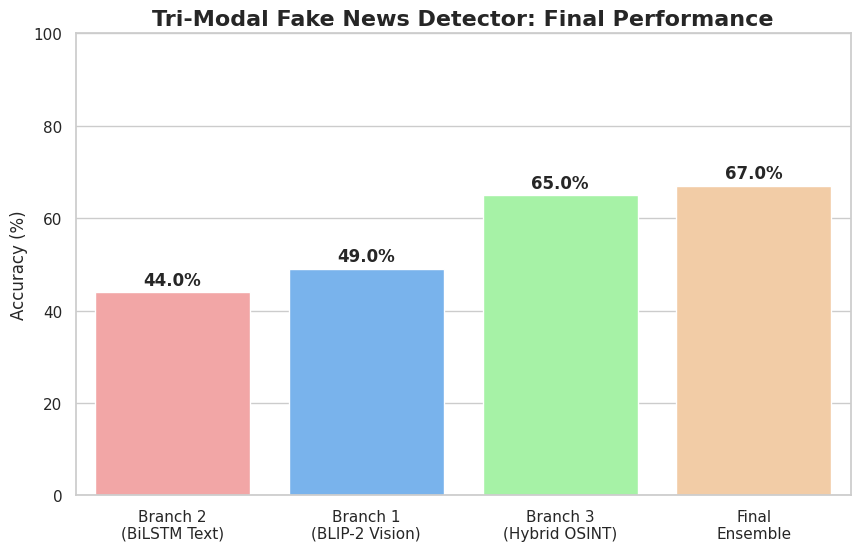

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your official final numbers
models = ['Branch 2\n(BiLSTM Text)', 'Branch 1\n(BLIP-2 Vision)', 'Branch 3\n(Hybrid OSINT)', 'Final\nEnsemble']
accuracies = [44.0, 49.0, 65.0, 67.0]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=models, y=accuracies, palette=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])

plt.title('Tri-Modal Fake News Detector: Final Performance', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

# Add the numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.show()